# STFT / ISTFT Transform

| Function | Description |
| --- | --- |
| `stft` | Short-time Fourier transform. |
| `istft` | Inverse STFT via overlap-add. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_chirp
from python.time_frequency import istft, stft

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

STFT and ISTFT: forward transform, spectral modification, and reconstruction.

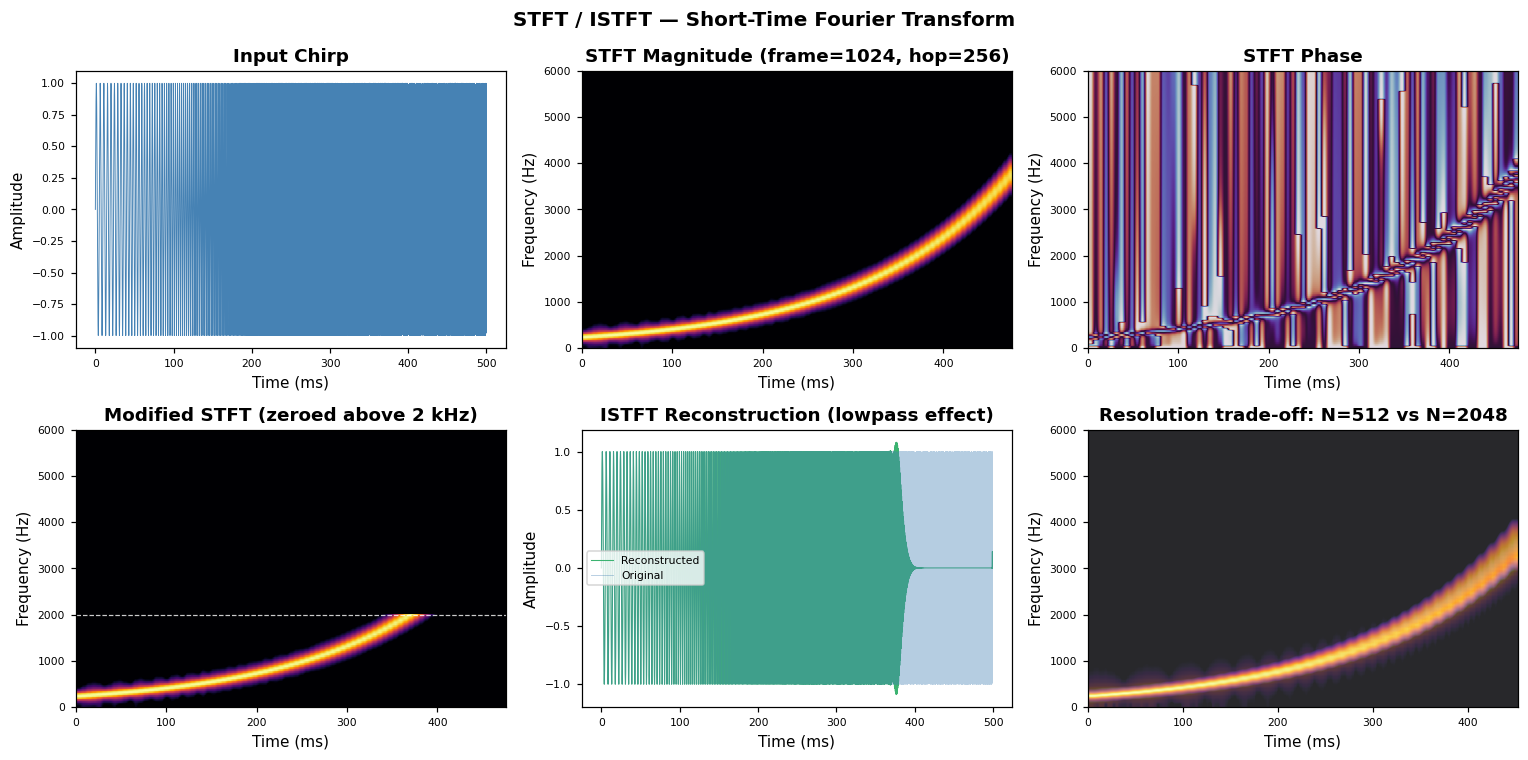

In [2]:
FS = 44100
DURATION = 0.5
FRAME = 1024
HOP = 256

_, sig = generate_chirp(f_start=200.0, f_end=4000.0, fs=FS, duration=DURATION)

S = stft(sig, frame_size=FRAME, hop_size=HOP)
mag = np.abs(S)
phase = np.angle(S)

# Spectral modification: zero out above 2000 Hz, then reconstruct
freq_axis = np.fft.rfftfreq(FRAME, d=1.0 / FS)
S_mod = S.copy()
S_mod[freq_axis > 2000, :] = 0.0
sig_reconstructed = istft(S_mod, hop_size=HOP)

t_ms = np.arange(len(sig)) / FS * 1000
frame_t = np.arange(S.shape[1]) * HOP / FS * 1000

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].plot(t_ms, sig, linewidth=0.6, color="steelblue")
axes[0, 0].set_title("Input Chirp", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")

db = 20 * np.log10(mag + 1e-12)
axes[0, 1].imshow(db, aspect="auto", origin="lower",
                  extent=[frame_t[0], frame_t[-1], 0, freq_axis[-1]],
                  vmin=db.max() - 60, vmax=db.max(), cmap="inferno")
axes[0, 1].set_title(f"STFT Magnitude (frame={FRAME}, hop={HOP})", fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)")
axes[0, 1].set_ylabel("Frequency (Hz)")
axes[0, 1].set_ylim(0, 6000)

axes[0, 2].imshow(phase, aspect="auto", origin="lower",
                  extent=[frame_t[0], frame_t[-1], 0, freq_axis[-1]],
                  cmap="twilight")
axes[0, 2].set_title("STFT Phase", fontweight="bold")
axes[0, 2].set_xlabel("Time (ms)")
axes[0, 2].set_ylabel("Frequency (Hz)")
axes[0, 2].set_ylim(0, 6000)

db_mod = 20 * np.log10(np.abs(S_mod) + 1e-12)
axes[1, 0].imshow(db_mod, aspect="auto", origin="lower",
                  extent=[frame_t[0], frame_t[-1], 0, freq_axis[-1]],
                  vmin=db.max() - 60, vmax=db.max(), cmap="inferno")
axes[1, 0].axhline(2000, color="white", linewidth=0.8, linestyle="--", alpha=0.8)
axes[1, 0].set_title("Modified STFT (zeroed above 2 kHz)", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Frequency (Hz)")
axes[1, 0].set_ylim(0, 6000)

n = min(len(t_ms), len(sig_reconstructed))
axes[1, 1].plot(t_ms[:n], sig_reconstructed[:n], linewidth=0.7, color="mediumseagreen", label="Reconstructed")
axes[1, 1].plot(t_ms[:n], sig[:n], linewidth=0.6, color="steelblue", alpha=0.4, label="Original")
axes[1, 1].set_title("ISTFT Reconstruction (lowpass effect)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Amplitude")
axes[1, 1].legend(fontsize=7)

# Resolution comparison
for (frame, hop, color, label) in [(512, 128, "steelblue", "N=512"), (2048, 512, "crimson", "N=2048")]:
    S2 = stft(sig, frame_size=frame, hop_size=hop)
    db2 = 20 * np.log10(np.abs(S2) + 1e-12)
    f2 = np.fft.rfftfreq(frame, d=1.0 / FS)
    t2 = np.arange(S2.shape[1]) * hop / FS * 1000
    axes[1, 2].imshow(db2, aspect="auto", origin="lower",
                      extent=[t2[0], t2[-1], 0, f2[-1]],
                      vmin=db2.max() - 60, vmax=db2.max(), cmap="inferno", alpha=0.6)
axes[1, 2].set_title("Resolution trade-off: N=512 vs N=2048", fontweight="bold")
axes[1, 2].set_xlabel("Time (ms)")
axes[1, 2].set_ylabel("Frequency (Hz)")
axes[1, 2].set_ylim(0, 6000)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)

fig.suptitle("STFT / ISTFT — Short-Time Fourier Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()